In [ ]:
import numpy as np
from scipy.integrate import odeint
from matplotlib import pyplot as plt 

dE_dt = kb * ES - kf * E * S + kcat * ES
dS_dt = kb * ES - kf * E * S
dES_dt = kf * E * S - kb * ES - kcat * ES
dP_dt = kcat * ES

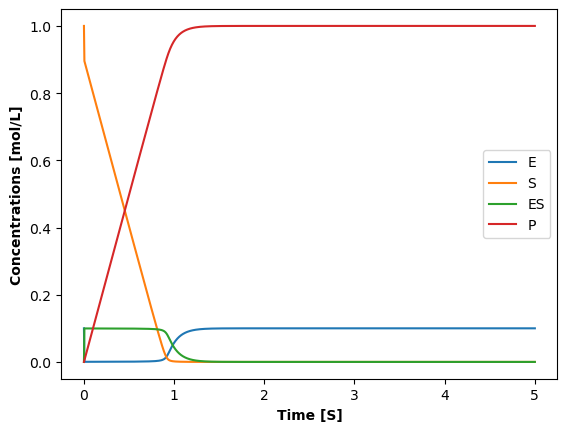

In [6]:
import numpy as np
from scipy.integrate import odeint
from matplotlib import pyplot as plt 

def equations(variables,t):
    E, S, ES, P = variables
    kb = 20 #s-1
    kf = 10000 #L/mol.s
    kcat = 10 #s-1
    dE_dt = kb * ES - kf * E * S + kcat * ES
    dS_dt = kb * ES - kf * E * S
    dES_dt = kf * E * S - kb * ES - kcat * ES
    dP_dt = kcat * ES
    return dE_dt, dS_dt, dES_dt, dP_dt

E0 = 0.1 #mol/L
S0 = 1 #mol/L
ES0 = P0 =  0 #mol/L
initial_conditions = [E0, S0, ES0, P0]

t=np.linspace(start=0, stop=5, num=1000)

results = odeint(equations, initial_conditions, t)

E, S, ES, P = results.T
plt.plot(t, E, t, S, t, ES, t, P)
plt.xlabel("Time [S]", fontweight = "bold")
plt.ylabel("Concentrations [mol/L]", fontweight = "bold")
plt.legend(["E", "S", "ES", "P"])
plt.show()


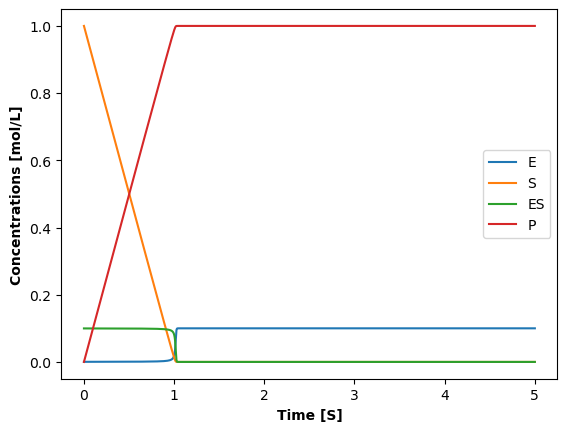

In [16]:
import numpy as np
from scipy.integrate import odeint
from matplotlib import pyplot as plt 

def equations_QSSA(variables,t):
    S, P = variables
    kb = 20 #s-1
    kf = 10000 #L/mol.s
    kcat = 10 #s-1
    ES = (kf * E0 * S)/(kcat+ kb + S * kf)
    E = E0 - ES
    dS_dt = kb * ES - kf * E * S
    dP_dt = kcat * ES
    return dS_dt, dP_dt

E0 = 0.1 #mol/L
S0 = 1 #mol/L
P0 =  0 #mol/L
initial_conditions = [S0, P0]


t=np.linspace(start=0, stop=5, num=1000)

results_QSSA = odeint(equations_QSSA, initial_conditions, t)

S, P = results_QSSA.T
plt.plot(t, E, t, S, t, ES, t, P)
plt.xlabel("Time [S]", fontweight = "bold")
plt.ylabel("Concentrations [mol/L]", fontweight = "bold")
plt.legend(["E", "S", "ES", "P"])
plt.show()


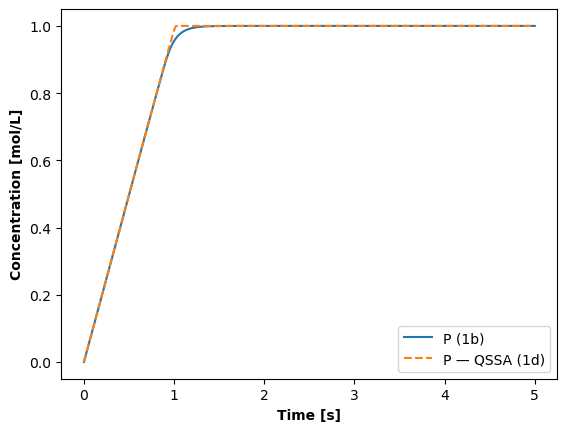

In [20]:
import numpy as np
from scipy.integrate import odeint
from matplotlib import pyplot as plt 

def equations(variables,t):
    E, S, ES, P = variables
    kb = 20 #s-1
    kf = 10000 #L/mol.s
    kcat = 10 #s-1
    dE_dt = kb * ES - kf * E * S + kcat * ES
    dS_dt = kb * ES - kf * E * S
    dES_dt = kf * E * S - kb * ES - kcat * ES
    dP_dt = kcat * ES
    return dE_dt, dS_dt, dES_dt, dP_dt

E0 = 0.1 #mol/L
S0 = 1 #mol/L
ES0 = P0 =  0 #mol/L
initial_conditions = [E0, S0, ES0, P0]

t=np.linspace(start=0, stop=5, num=1000)

results = odeint(equations, initial_conditions, t)

E, S, ES, P = results.T


def equations_QSSA(variables,t):
    S, P = variables
    kb = 20 #s-1
    kf = 10000 #L/mol.s
    kcat = 10 #s-1
    ES = (kf * E0 * S)/(kcat+ kb + S * kf)
    E = E0 - ES
    dS_dt = kb * ES - kf * E * S
    dP_dt = kcat * ES
    return dS_dt, dP_dt

E0 = 0.1 #mol/L
S0 = 1 #mol/L
P0 =  0 #mol/L
initial_conditions = [S0, P0]


t=np.linspace(start=0, stop=5, num=1000)

results_QSSA = odeint(equations_QSSA, initial_conditions, t)
P_QSSA = results_QSSA.T[1]

plt.plot(t, P, label="P (1b)")
plt.plot(t, P_QSSA, label="P — QSSA (1d)", linestyle="--")
plt.xlabel("Time [s]", fontweight="bold")
plt.ylabel("Concentration [mol/L]", fontweight="bold")
plt.legend()
plt.show()

In [ ]:
KM = (kb + kcat)/kf

#at t=0
v= (vmax * S0)/(Km + S0)

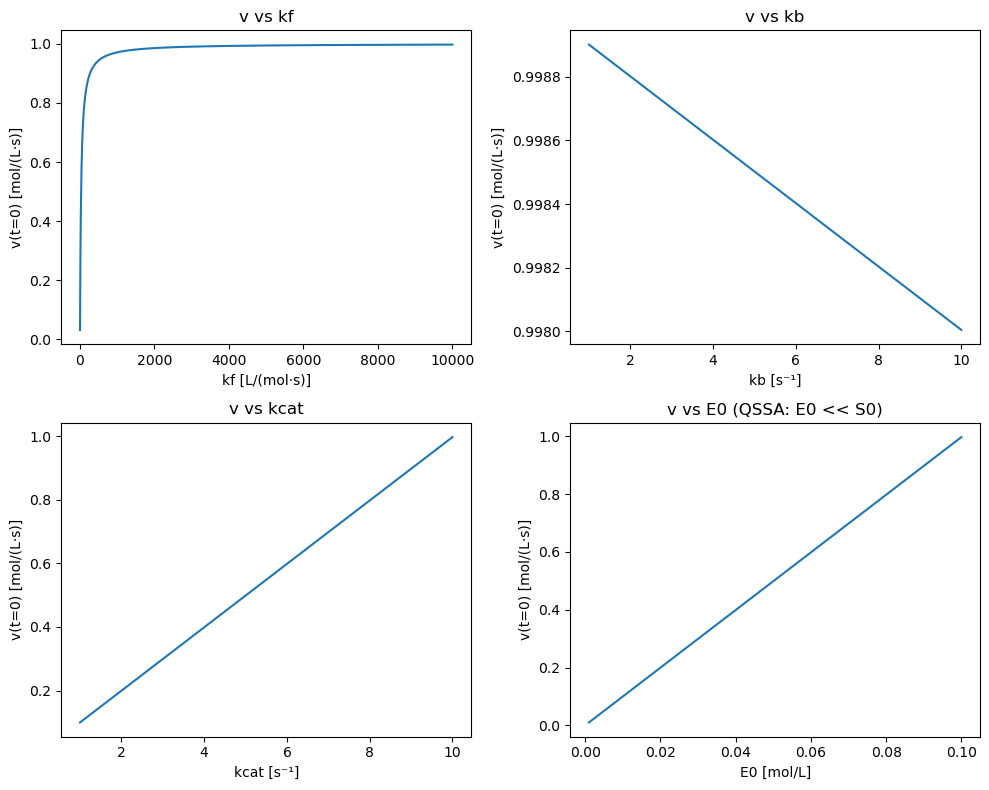

In [21]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 1.0  # mol/L
E0 = 0.1  # mol/L (fixe pour les variations de paramètres)

# Valeurs fixes de référence
kf_ref   = 10000
kb_ref   = 20
kcat_ref = 10

# ---- Variation de kf ----
kf_range = np.linspace(1, 1e4, 1000)  # L/(mol·s)
Km  = (kb_ref + kcat_ref) / kf_range
v_kf = kcat_ref * E0 * S0 / (Km + S0)

# ---- Variation de kb ----
kb_range = np.linspace(1, 10, 1000)  # s⁻¹
Km  = (kb_range + kcat_ref) / kf_ref
v_kb = kcat_ref * E0 * S0 / (Km + S0)

# ---- Variation de kcat ----
kcat_range = np.linspace(1, 10, 1000)  # s⁻¹
Km  = (kb_ref + kcat_range) / kf_ref
v_kcat = kcat_range * E0 * S0 / (Km + S0)

# ---- Variation de E0 (doit respecter QSSA : E0 << S0) ----
E0_range = np.linspace(0.001, 0.1, 1000)  # E0 << S0 = 1
Km  = (kb_ref + kcat_ref) / kf_ref
v_E0 = kcat_ref * E0_range * S0 / (Km + S0)

# ---- Tracé ----
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].plot(kf_range, v_kf)
axes[0,0].set_xlabel("kf [L/(mol·s)]")
axes[0,0].set_ylabel("v(t=0) [mol/(L·s)]")
axes[0,0].set_title("v vs kf")

axes[0,1].plot(kb_range, v_kb)
axes[0,1].set_xlabel("kb [s⁻¹]")
axes[0,1].set_ylabel("v(t=0) [mol/(L·s)]")
axes[0,1].set_title("v vs kb")

axes[1,0].plot(kcat_range, v_kcat)
axes[1,0].set_xlabel("kcat [s⁻¹]")
axes[1,0].set_ylabel("v(t=0) [mol/(L·s)]")
axes[1,0].set_title("v vs kcat")

axes[1,1].plot(E0_range, v_E0)
axes[1,1].set_xlabel("E0 [mol/L]")
axes[1,1].set_ylabel("v(t=0) [mol/(L·s)]")
axes[1,1].set_title("v vs E0 (QSSA: E0 << S0)")

plt.tight_layout()
plt.show()

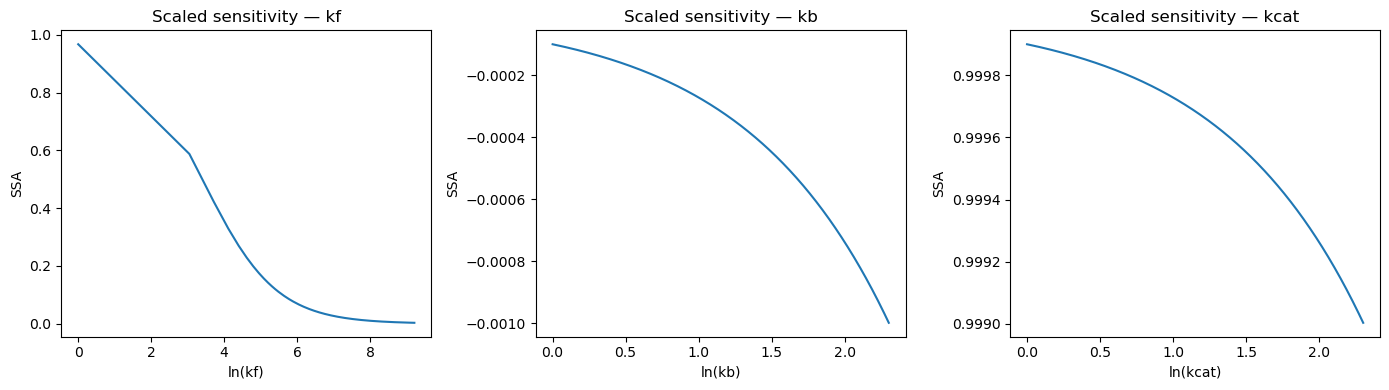

In [22]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 1.0
E0 = 0.1

kf_ref   = 10000
kb_ref   = 20
kcat_ref = 10

def v_func(kf, kb, kcat, E0):
    Km = (kb + kcat) / kf
    return kcat * E0 * S0 / (Km + S0)

def scaled_sensitivity(param_range, param_name):
    SSA = []
    for p in param_range:
        dp = p * 1e-5  # petite perturbation

        if param_name == "kf":
            v_plus  = v_func(p + dp, kb_ref, kcat_ref, E0)
            v_minus = v_func(p - dp, kb_ref, kcat_ref, E0)
            v       = v_func(p,      kb_ref, kcat_ref, E0)
        elif param_name == "kb":
            v_plus  = v_func(kf_ref, p + dp, kcat_ref, E0)
            v_minus = v_func(kf_ref, p - dp, kcat_ref, E0)
            v       = v_func(kf_ref, p,      kcat_ref, E0)
        elif param_name == "kcat":
            v_plus  = v_func(kf_ref, kb_ref, p + dp, E0)
            v_minus = v_func(kf_ref, kb_ref, p - dp, E0)
            v       = v_func(kf_ref, kb_ref, p,      E0)

        dvdp = (v_plus - v_minus) / (2 * dp)
        SSA.append(dvdp * (p / v))
    return np.array(SSA)

# Plages
kf_range   = np.linspace(1, 1e4, 500)
kb_range   = np.linspace(1, 10,  500)
kcat_range = np.linspace(1, 10,  500)

SSA_kf   = scaled_sensitivity(kf_range,   "kf")
SSA_kb   = scaled_sensitivity(kb_range,   "kb")
SSA_kcat = scaled_sensitivity(kcat_range, "kcat")

# Tracé SSA vs log(paramètre)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(np.log(kf_range), SSA_kf)
axes[0].set_xlabel("ln(kf)")
axes[0].set_ylabel("SSA")
axes[0].set_title("Scaled sensitivity — kf")

axes[1].plot(np.log(kb_range), SSA_kb)
axes[1].set_xlabel("ln(kb)")
axes[1].set_ylabel("SSA")
axes[1].set_title("Scaled sensitivity — kb")

axes[2].plot(np.log(kcat_range), SSA_kcat)
axes[2].set_xlabel("ln(kcat)")
axes[2].set_ylabel("SSA")
axes[2].set_title("Scaled sensitivity — kcat")

plt.tight_layout()
plt.show()